### ticker의 의미
=> 주식시장에서 각 기업의 주식을 식별하는 고유한 코드  
### 분석하는 이유
2021년 7월부터 주식구매 후 흐름을 보기 위해서 

In [24]:
!pip install yfinance
import yfinance as yf #야후 파이낸스(Yahoo Finance)에서 주식 데이터를 가져오는 파이썬 라이브러리
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
ticker = "096770.KS" 
stock_data = yf.download(ticker, start="2021-07-01", end="2025-01-01")
print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price               Close           High            Low           Open  \
Ticker          096770.KS      096770.KS      096770.KS      096770.KS   
Date                                                                     
2021-07-01  255248.796875  283188.826415  253828.125087  280821.045310   
2021-07-02  255248.796875  259984.405960  250039.640944  252407.437674   
2021-07-05  256195.921875  259510.843548  255248.796933  256195.921875   
2021-07-06  262352.187500  262352.187500  257616.578689  257616.578689   
2021-07-07  258090.156250  260931.515453  256669.484461  260457.952982   

Price         Volume  
Ticker     096770.KS  
Date                  
2021-07-01   5751164  
2021-07-02   2169055  
2021-07-05    809565  
2021-07-06    967792  
2021-07-07    613386  


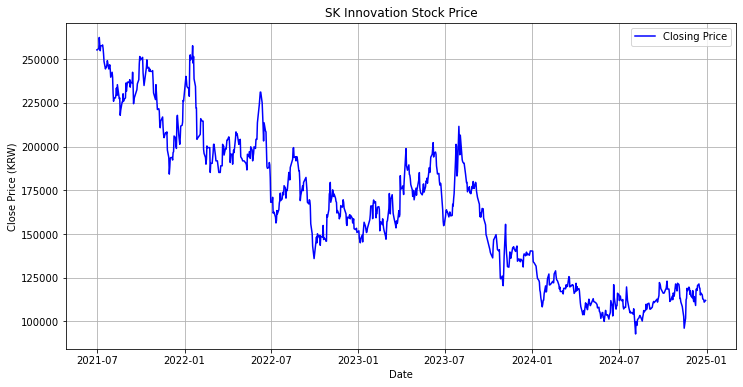

In [26]:
def plot_stock_prices(stock_df):
    plt.figure(figsize=(12, 6))
    plt.plot(stock_df["Close"], label="Closing Price", color="blue")
    plt.title("SK Innovation Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price (KRW)")
    plt.legend()
    plt.grid()
    plt.show()

plot_stock_prices(stock_data)


In [27]:
# 이동 평균선 추가(20일, 50일)
stock_data['MA20'] = stock_data['Close'].rolling(window=20).mean()
stock_data['MA50'] = stock_data['Close'].rolling(window=50).mean()

In [28]:
print(stock_data.head())

Price               Close           High            Low           Open  \
Ticker          096770.KS      096770.KS      096770.KS      096770.KS   
Date                                                                     
2021-07-01  255248.796875  283188.826415  253828.125087  280821.045310   
2021-07-02  255248.796875  259984.405960  250039.640944  252407.437674   
2021-07-05  256195.921875  259510.843548  255248.796933  256195.921875   
2021-07-06  262352.187500  262352.187500  257616.578689  257616.578689   
2021-07-07  258090.156250  260931.515453  256669.484461  260457.952982   

Price         Volume MA20 MA50  
Ticker     096770.KS            
Date                            
2021-07-01   5751164  NaN  NaN  
2021-07-02   2169055  NaN  NaN  
2021-07-05    809565  NaN  NaN  
2021-07-06    967792  NaN  NaN  
2021-07-07    613386  NaN  NaN  


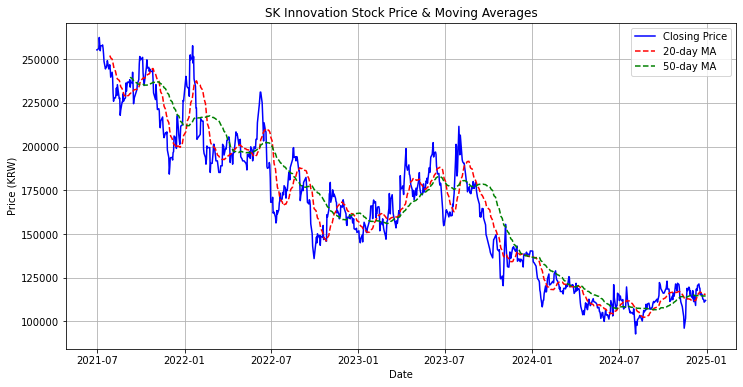

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'], label='Closing Price', color='blue')
plt.plot(stock_data['MA20'], label='20-day MA', color='red', linestyle='dashed')
plt.plot(stock_data['MA50'], label='50-day MA', color='green', linestyle='dashed')
plt.title("SK Innovation Stock Price & Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (KRW)")
plt.legend()
plt.grid()
plt.show()

In [30]:
# 주가 변화율 계산
stock_data['Daily Return'] = stock_data['Close'].pct_change()

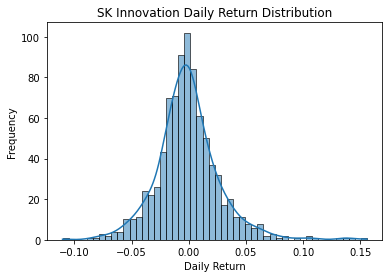

In [31]:
# 수익률 분포 확인
sns.histplot(stock_data['Daily Return'].dropna(), bins=50, kde=True)
plt.title("SK Innovation Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [32]:
# 간단한 예측 모델 (ARIMA 예측 예제)
from statsmodels.tsa.arima.model import ARIMA

# 주가 종가 예측
model = ARIMA(stock_data['Close'].dropna(), order=(5,1,0))
model_fit = model.fit()

C:\Users\dlago\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\dlago\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\dlago\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'


In [40]:
# 향후 30일 예측
forecast = model_fit.forecast(steps=60)

C:\Users\dlago\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:376: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  warnings.warn('No supported index is available.'


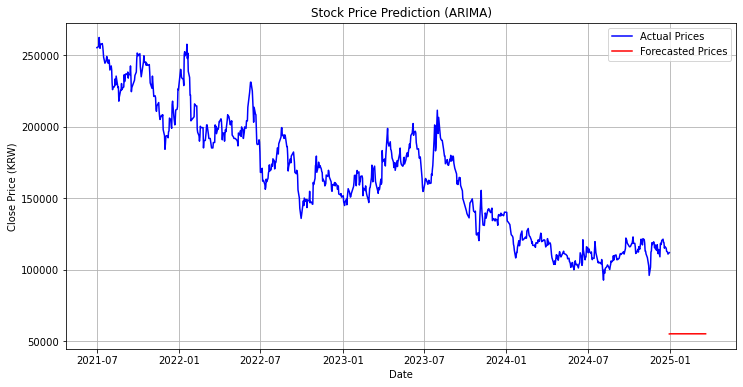

In [42]:
# 예측 시각화
plt.figure(figsize=(12,6))
plt.plot(stock_data['Close'], label='Actual Prices', color='blue')
plt.plot(pd.date_range(skt_stock.index[-1], periods=60, freq='B'), forecast, label='Forecasted Prices', color='red')
plt.title("Stock Price Prediction (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Close Price (KRW)")
plt.legend()
plt.grid()
plt.show()

### 분석결과
점점 내려가는 추세고 너무 고점에서 샀기 때문에 손절해야겠음....